# Genetic Rock Paper Scissors

The original paper shows how, in a _three-way_ prey-predator model, the
unexpected emerging behavior is a sort of _survival of the weakest_, where the
least aggressive species are the ones the most likely will have an higher
population density.

The model does not involve movement but only space conquering by hunting a
nearby cell, which will host the offspring of the predator. The offspring
inherit the invasion probability from the father

- Just by copying it:
  $$ p_\text{new} = p_\text{old} $$
- With a random mutation:
  $$ p_\text{new} = p_\text{old} + \varepsilon $$
  with $\varepsilon \sim \cal{N} (0, 0.05)$

The study shows mainly two cases: 

- Two of the three species invasion probability are held constant, while the
  third is free to evolve through random mutations.
- All three species are free to mutate.

The paper also says how the mutation, in general, drive the population to be
more aggressive on average, that results in:

- A reduced population of the specie free to evolve (first case).
- A dynamical equilibrium, made possible by all three species reaching maximal
  aggression (second case).

In [26]:
import pandas as pd
from grps.utils import (
    plot_densities,
    plot_average_invasions,
    plot_average_age,
    plot_orbits,
)

## Paper Results Reproduction

The first thing to do is to have a baseline by reproducing the dynamics
described in the paper on a $75 \times 75$ and a maximum of $500$ epochs
simulation. 

The grid is randomly initialized by sampling one of the three species for each
cell with equal probability.

### Inheritance

The first case of study assigns at each specie individual an invasion
probability, which will inhertied by their offsprings after the reproduction.

Here the goal is just to reproduce the main result of the paper (survival of the
weakest), by assigning a lower invasion probability to one of the three species
and see if in the end it has the highest population density.

In [27]:
in_df = pd.read_csv("results/inheritance.csv")
in_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy
0,1802,1934,1889,0.2,0.5,0.5,0.000000,0.000000,0.000000,0,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
1,1668,1829,2128,0.2,0.5,0.5,1.000000,1.000000,1.000000,1,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
2,1549,1730,2346,0.2,0.5,0.5,1.932860,1.873410,1.863171,2,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
3,1472,1657,2496,0.2,0.5,0.5,2.766984,2.646349,2.655849,3,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
4,1415,1516,2694,0.2,0.5,0.5,3.547703,3.351583,3.346696,4,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,2560,951,2114,0.2,0.5,0.5,18.758984,7.093586,20.196310,995,3,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
3996,2542,955,2128,0.2,0.5,0.5,18.803698,7.144503,19.880169,996,3,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
3997,2515,958,2152,0.2,0.5,0.5,19.009145,7.132568,19.680297,997,3,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
3998,2512,975,2138,0.2,0.5,0.5,19.056131,7.326154,19.646866,998,3,75,0.2,0.5,0.5,inheritance,inheritance,inheritance


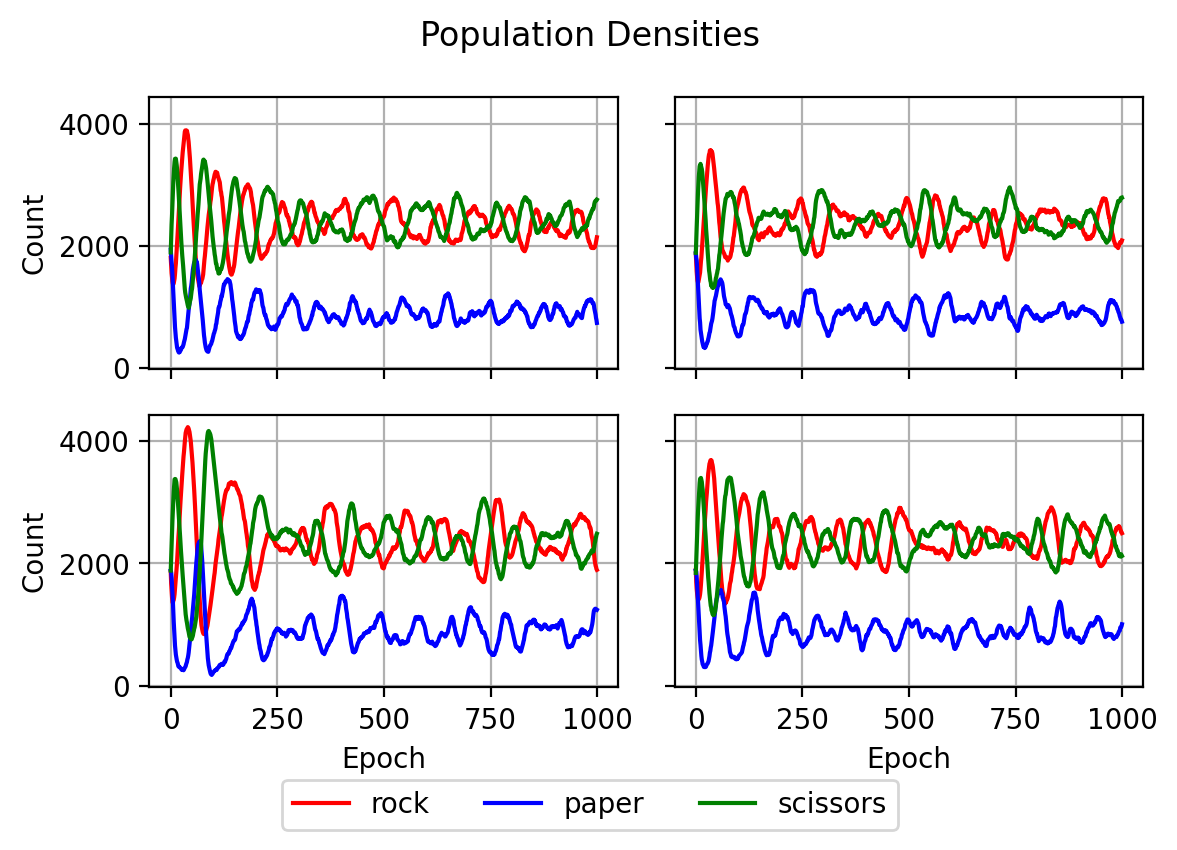

In [28]:
plot_densities(in_df)

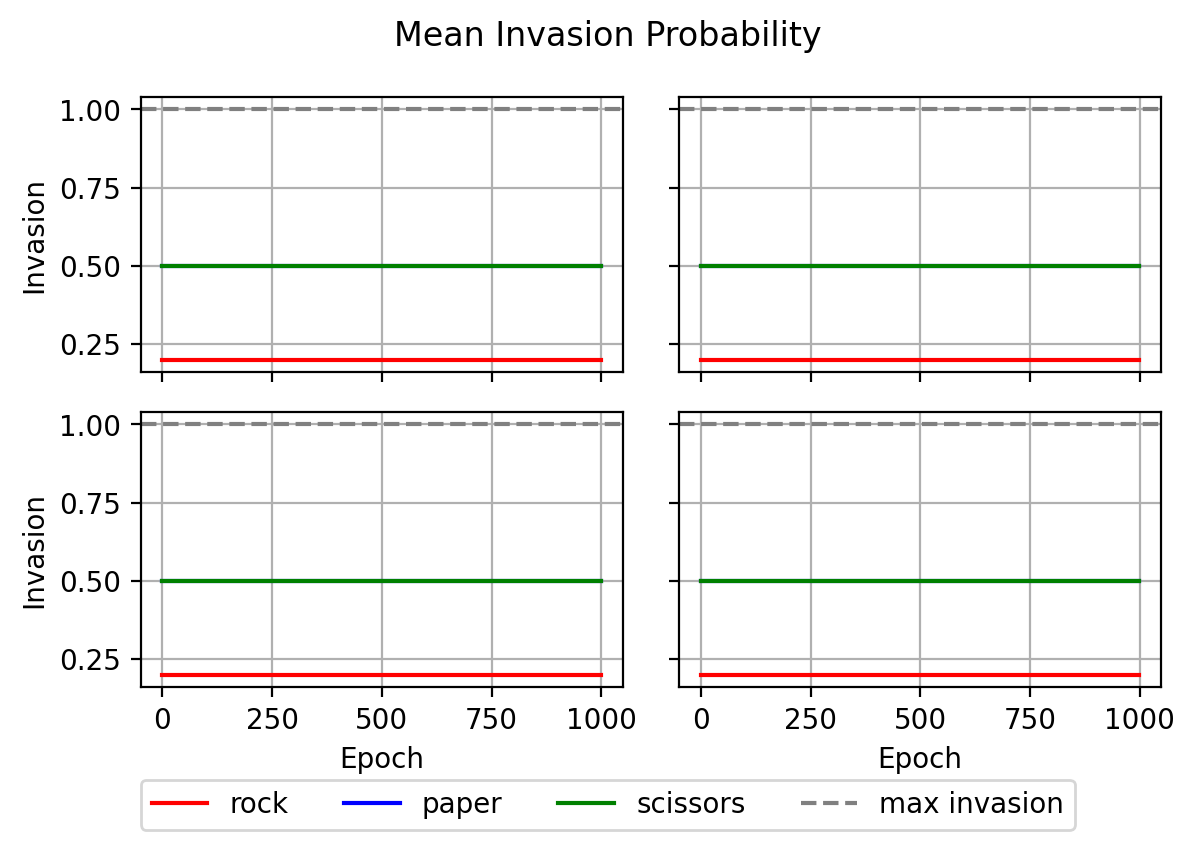

In [29]:
plot_average_invasions(in_df)

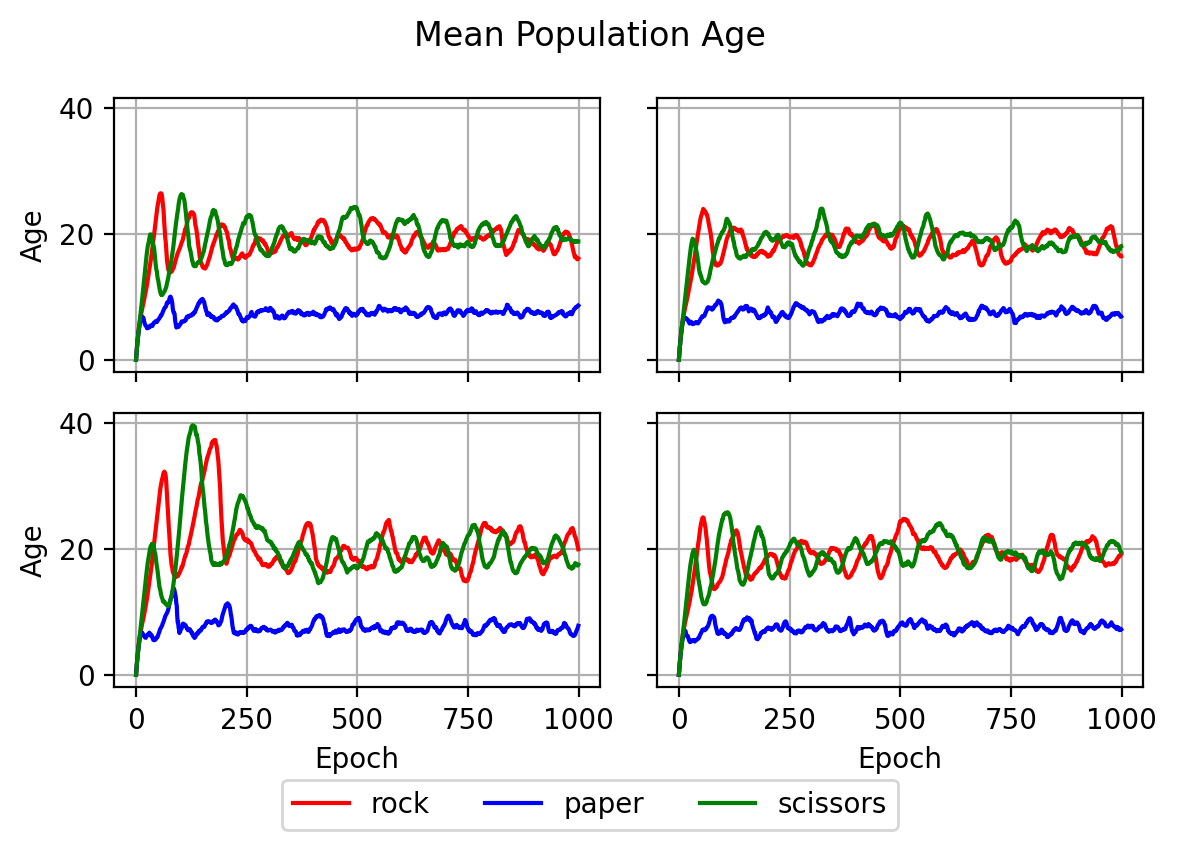

In [30]:
plot_average_age(in_df)

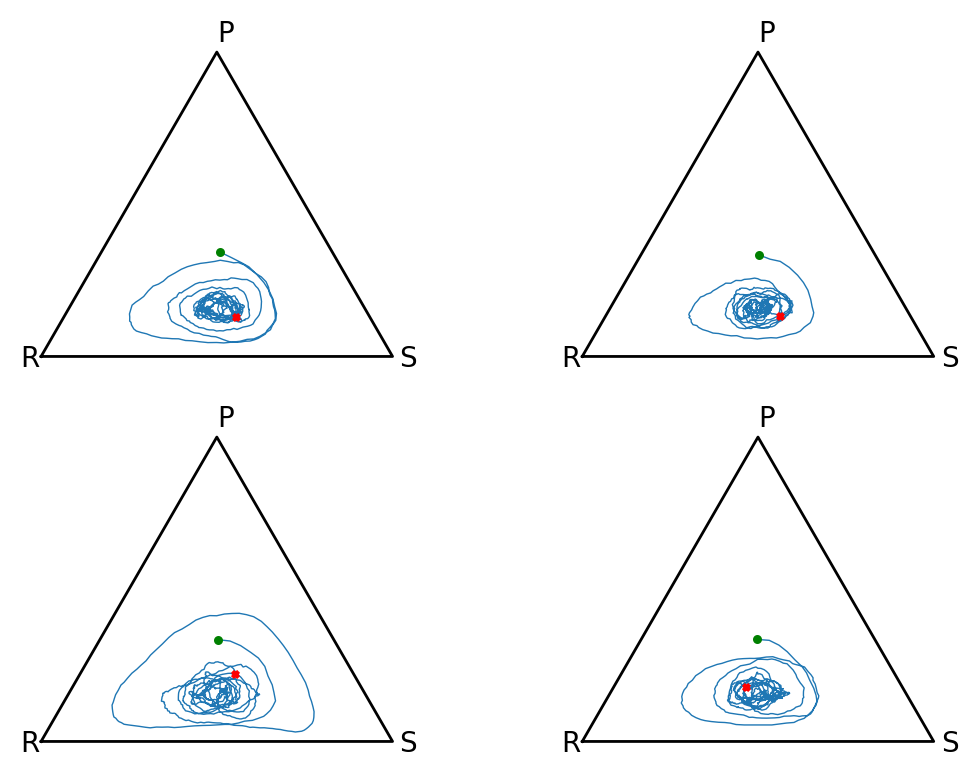

In [31]:
plot_orbits(in_df)

### Stochastic Mutation of 1 Specie

The other main result shown was obtained by keeping two species invasion
probabilites fixed, while the third is let free to mutate.

Here the end result can vary, depending on initial conditions and initial
invasion probabilities assigned to each specie.

In the following simulations are shown two main scenarios:

- Every specie starts with an initial invasion rate of $0.5$.
- The evolvable specie starts with a low invasion rate of $0.2$.

The two models might converge to the same result, since in the paper is said
that the mutated specie tends to be more aggressive in the end.

In [32]:
s1_df = pd.read_csv("results/stochastic1.csv")
s1_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma
0,1802,1934,1889,0.200000,0.5,0.5,0.000000,0.000000,0.000000,0,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.01
1,1665,1843,2117,0.200020,0.5,0.5,1.000000,1.000000,1.000000,1,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.01
2,1538,1748,2339,0.200073,0.5,0.5,1.932380,1.868421,1.860197,2,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.01
3,1460,1651,2514,0.200059,0.5,0.5,2.783562,2.654149,2.642800,3,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.01
4,1413,1523,2689,0.200136,0.5,0.5,3.544940,3.357846,3.346225,4,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1631,2590,1404,0.617661,0.5,0.5,9.108522,9.974517,7.410256,995,3,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.01
3996,1577,2630,1418,0.617401,0.5,0.5,9.032340,10.134981,7.306770,996,3,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.01
3997,1530,2628,1467,0.616438,0.5,0.5,8.924183,10.259893,7.173142,997,3,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.01
3998,1451,2639,1535,0.615372,0.5,0.5,8.952447,10.330428,7.131596,998,3,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.01


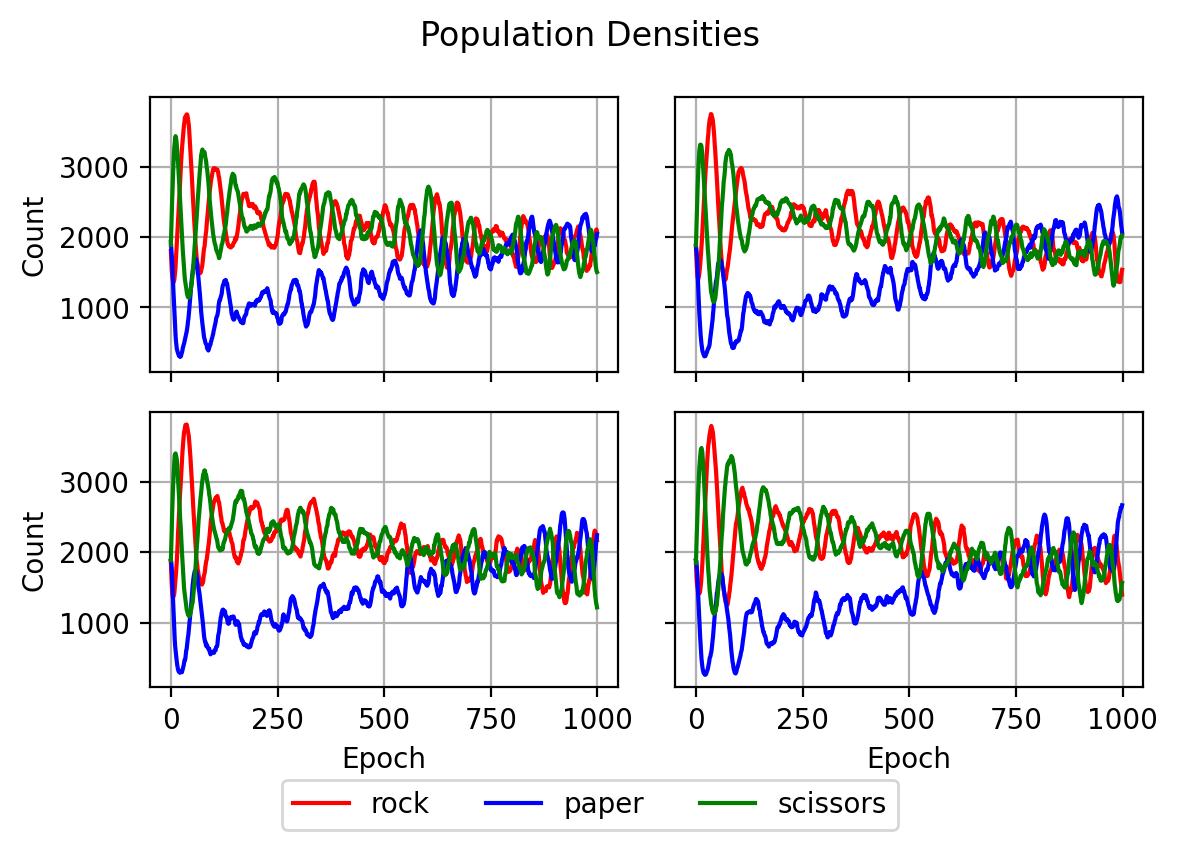

In [33]:
plot_densities(s1_df)

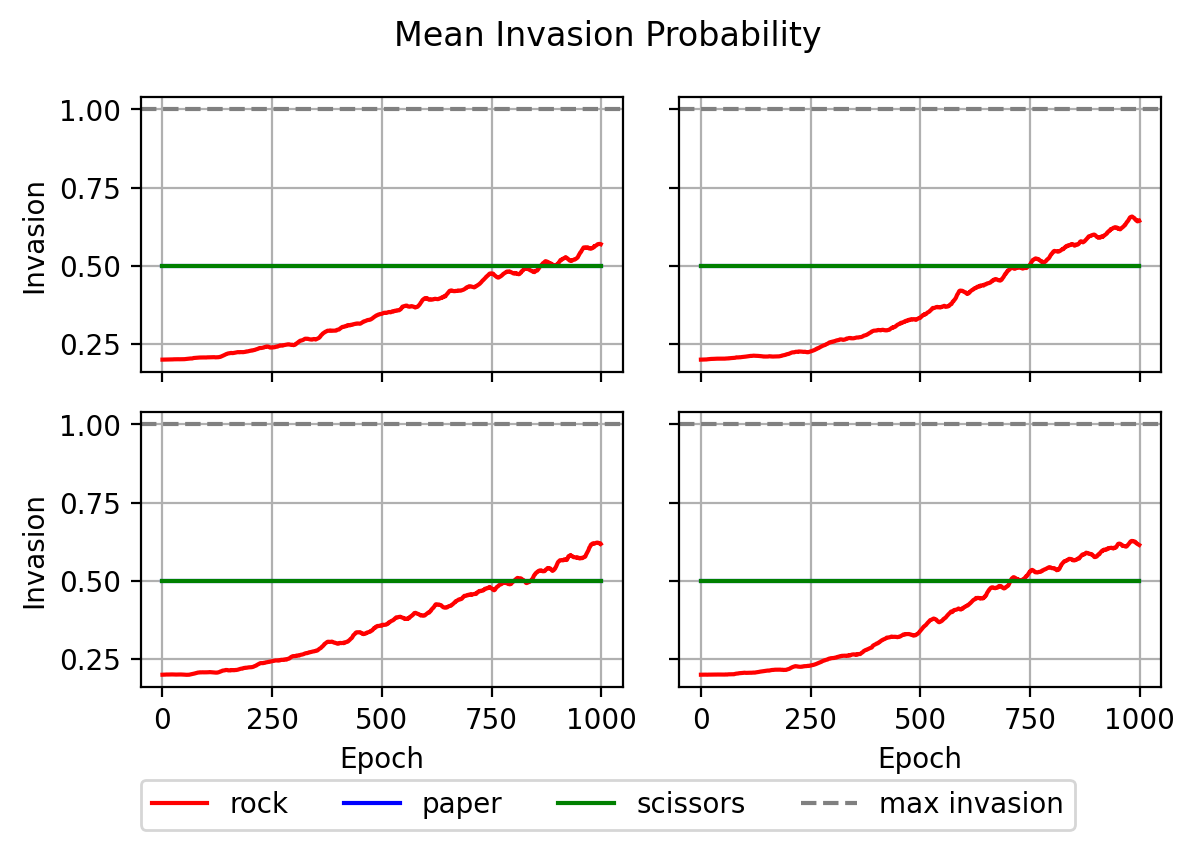

In [34]:
plot_average_invasions(s1_df)

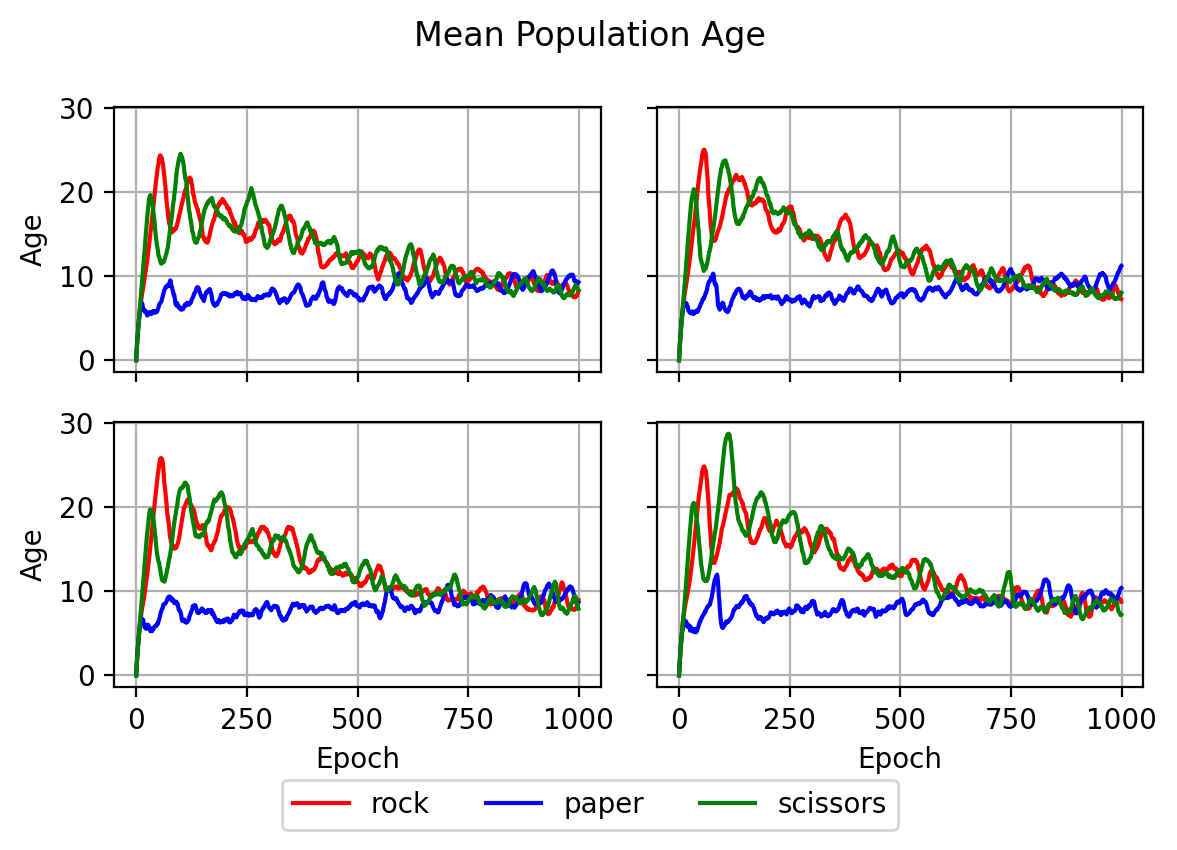

In [35]:
plot_average_age(s1_df)

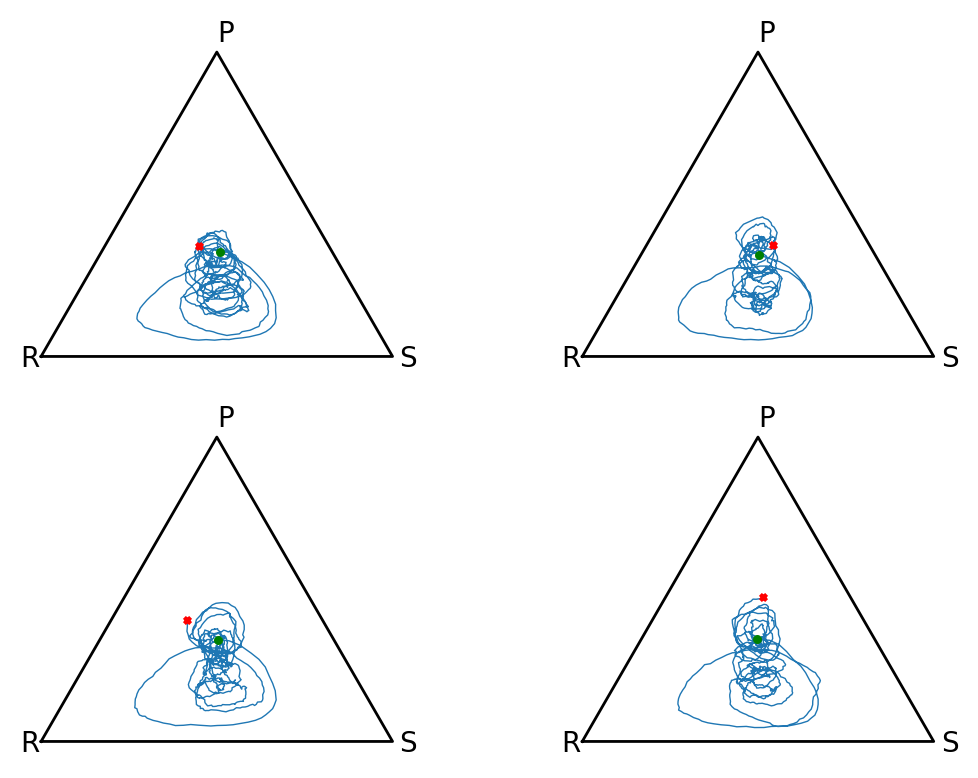

In [36]:
plot_orbits(s1_df)

Also for this setup nothing really surprising: since rock starts with a low
invasion probability, its population grows fast but more aggressive over time.

After few iterations the invasion rate is already at $0.5$ and after a few more
reaches values between $0.8$ and $0.9$ that, depending on the specific case,
leads to a decrease in population

### Stochastic Mutation of 3 Species

Another experiment consists in let all three species evolve via random
mutations, in the paper is mentioned how an equilibrium through maximal
aggression should be reached. 

It follows just a simulation in which every specie starts with an invasion
probability of $0.5$.

In [37]:
s3_df = pd.read_csv("results/stochastic3.csv")
s3_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma
0,1802,1934,1889,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,75,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.01
1,1829,1878,1918,0.499858,0.499896,0.499854,1.000000,1.000000,1.000000,1,0,75,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.01
2,1863,1843,1919,0.499711,0.500053,0.499748,1.842190,1.857298,1.844711,2,0,75,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.01
3,1860,1889,1876,0.499743,0.500053,0.499868,2.575806,2.590789,2.621002,3,0,75,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.01
4,1824,1942,1859,0.499625,0.500079,0.499819,3.233553,3.212667,3.292093,4,0,75,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,2153,1946,1526,0.935542,0.940095,0.922788,5.491407,4.495889,4.949541,995,3,75,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.01
3996,2146,2002,1477,0.934713,0.941056,0.920846,5.369525,4.565435,4.816520,996,3,75,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.01
3997,2058,2113,1454,0.933907,0.941276,0.918374,5.436832,4.577378,4.678129,997,3,75,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.01
3998,1988,2190,1447,0.933162,0.940733,0.917689,5.520121,4.726941,4.528680,998,3,75,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.01


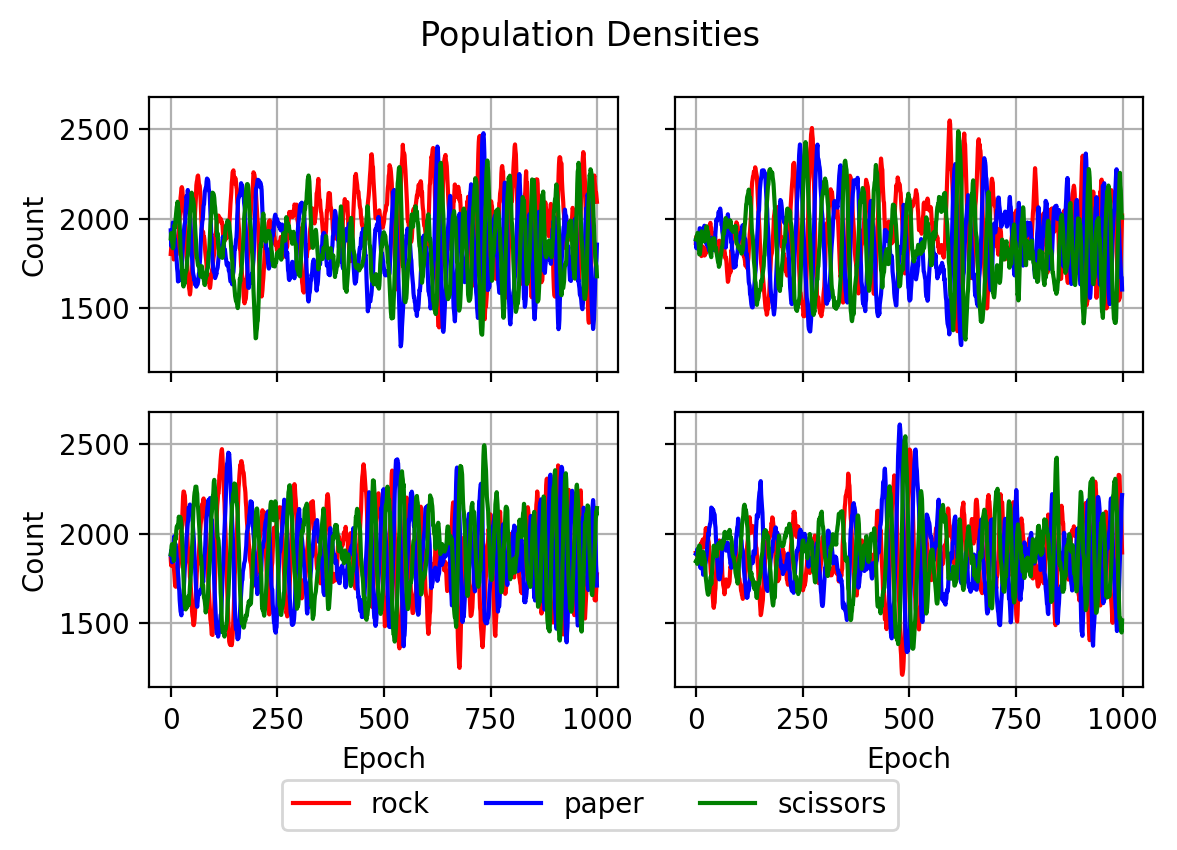

In [38]:
plot_densities(s3_df)

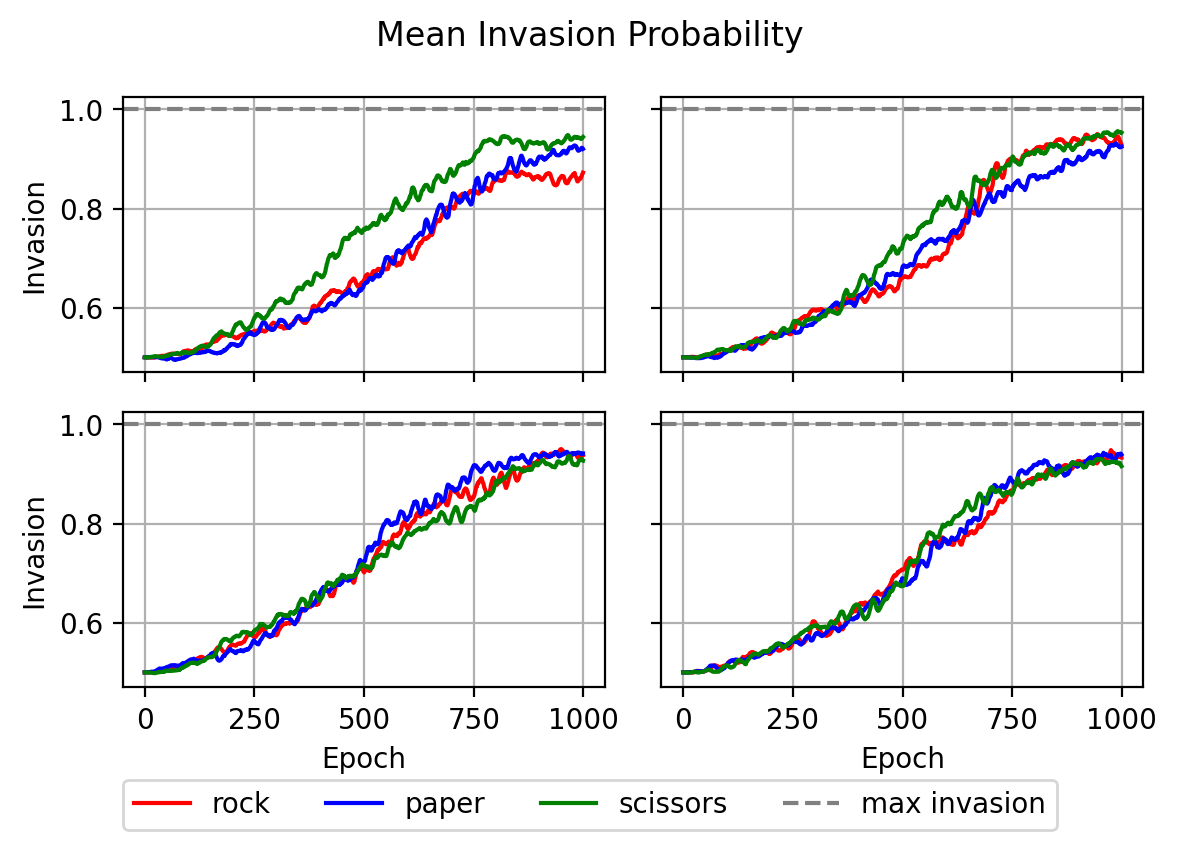

In [39]:
plot_average_invasions(s3_df)

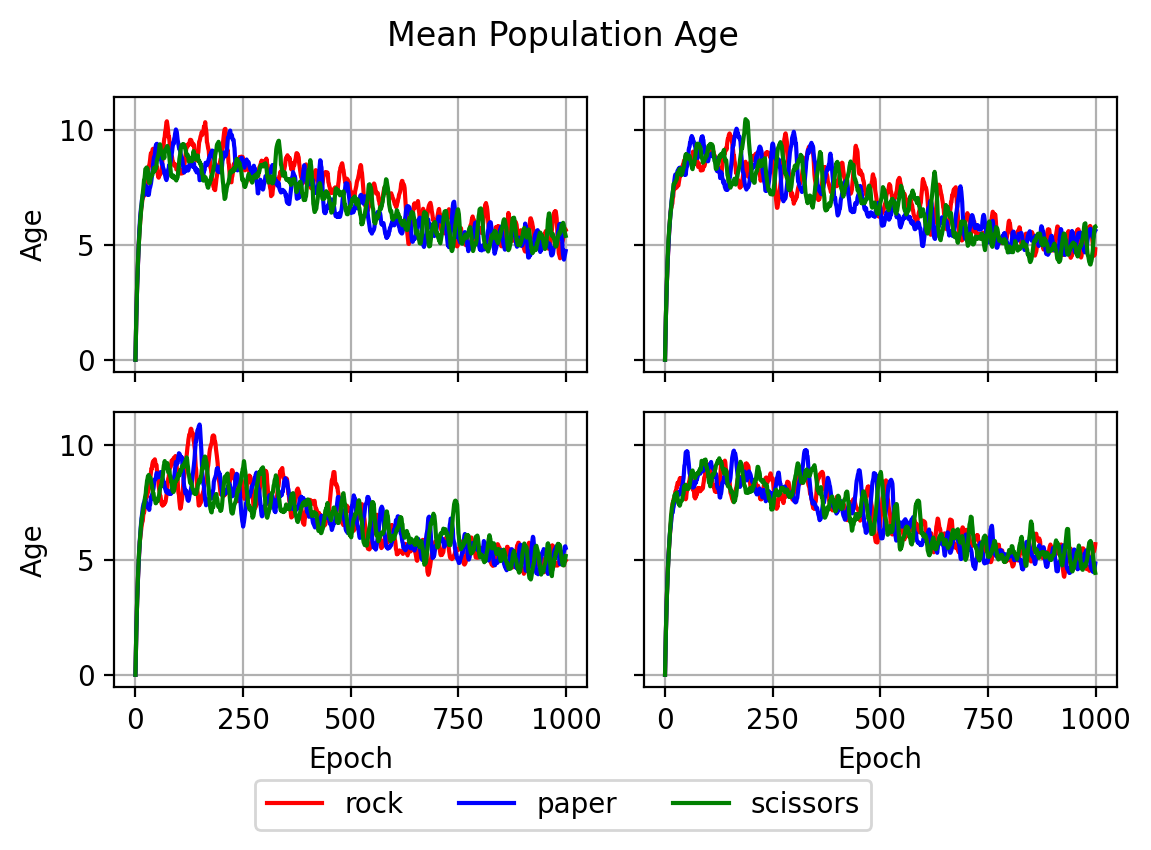

In [40]:
plot_average_age(s3_df)

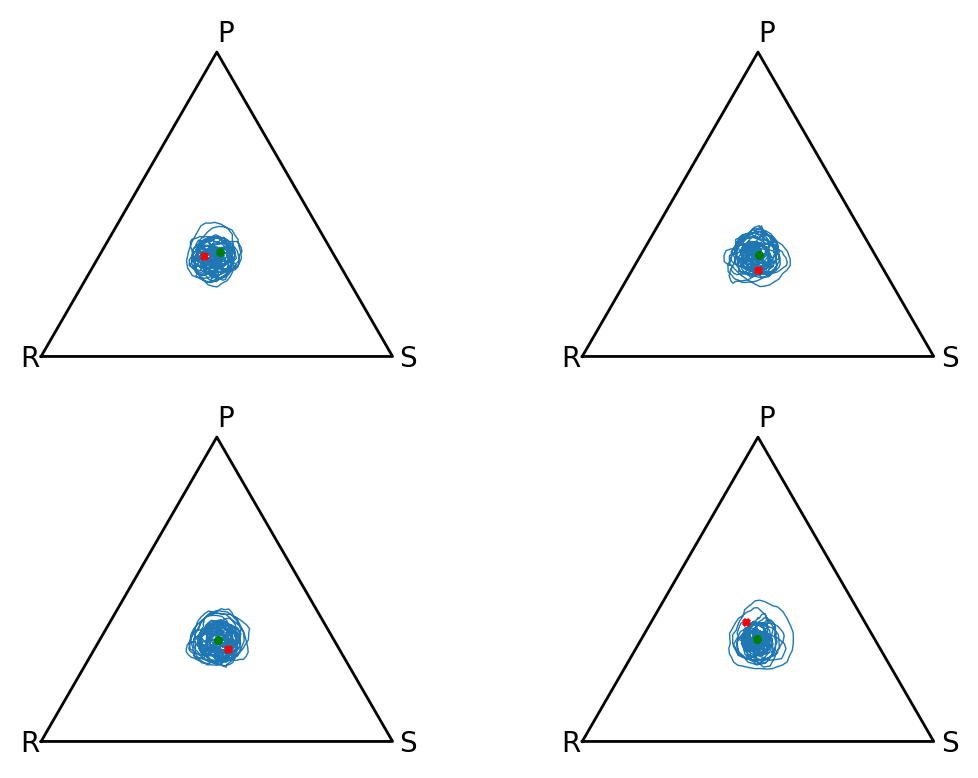

In [41]:
plot_orbits(s3_df)

## Proposed Extension

The proposed extension tries to introduce a more structured evolution approach,
by adding a **mating** mechasism based on a _fitness_ value (the age) and the
distance from the predator.

The idea is based on the assumption that older individuals may have a better
survival strategy. Therefore, when an individual hunts a prey, produces an
offspring with a invasion rate computed as the weighted mean between its
father's and a nearby individual with (hopefully) high fitness.

The idea is to sample an individual of the same specie within a certain radius
in order to maintain the simulation dynamics local. The final mate for
reproduction is sampled, weighted by its fitness.

The candidates are chosen within the radius accordingly with the Chebyshev
distance, which basically defines squared rings around the individual.

![Chebyshev Distance](images/chebyshev_distance.png)

### Genetic vs Stochastic

The other comparison was done by letting two of the species evolve by stochastic
mutations, while the third was optimized with the genetic approach.

In [42]:
g1_2s_df = pd.read_csv("results/genetic3_s2.csv")
g1_2s_df

FileNotFoundError: [Errno 2] File o directory non esistente: 'results/genetic3_s2.csv'

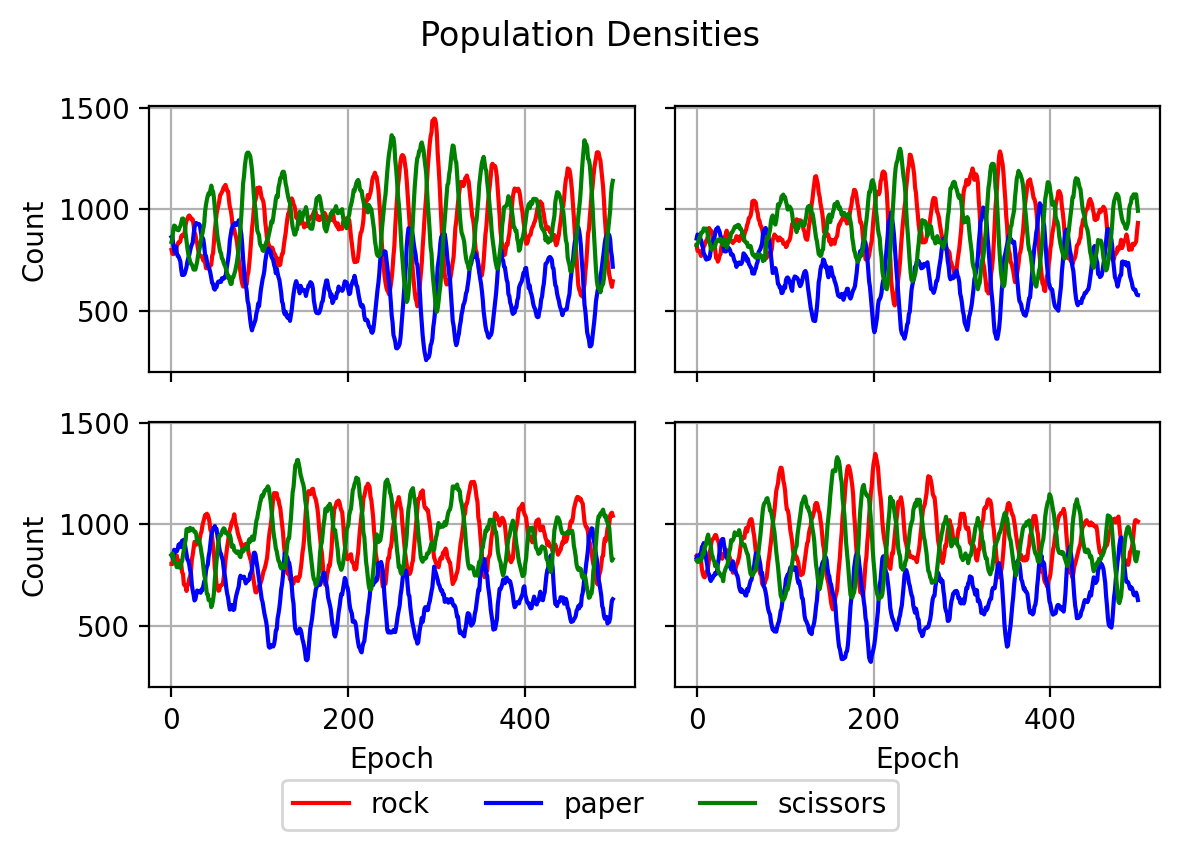

In [ ]:
plot_densities(g1_2s_df)

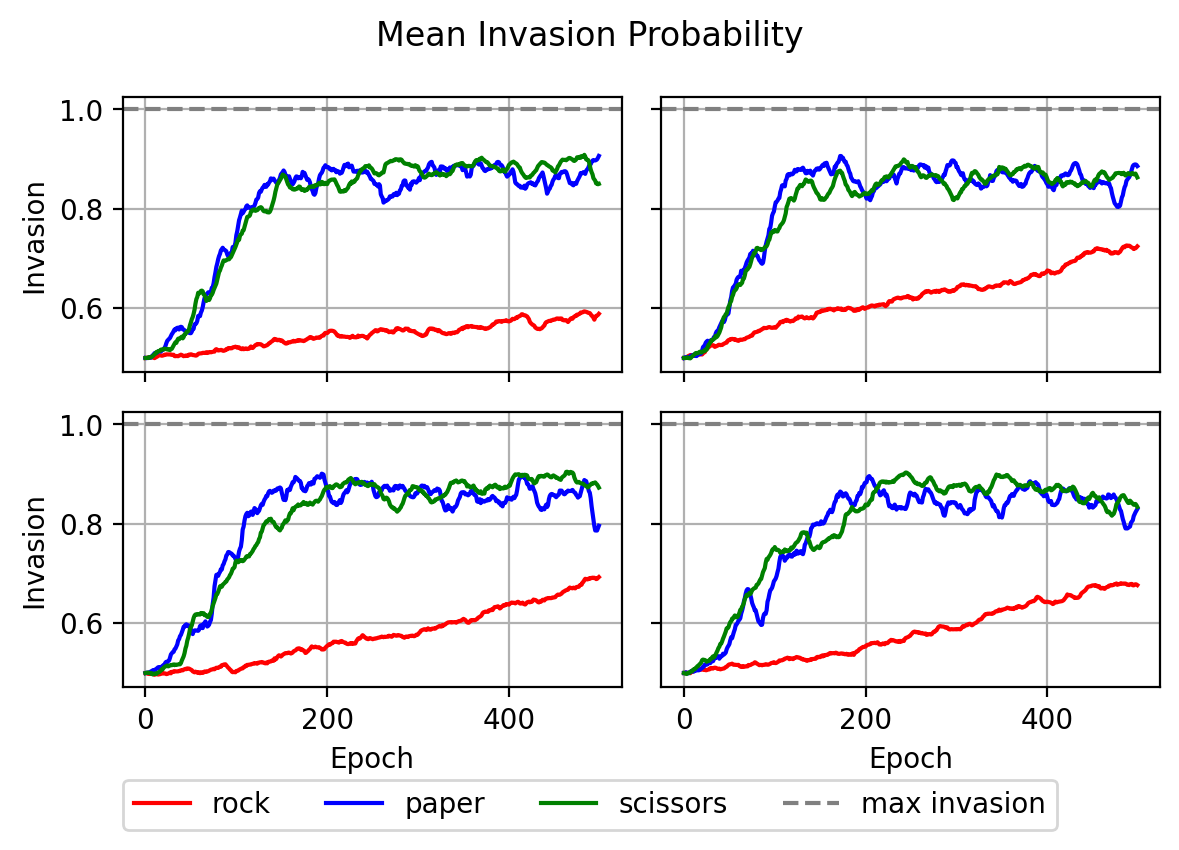

In [ ]:
plot_average_invasions(g1_2s_df)

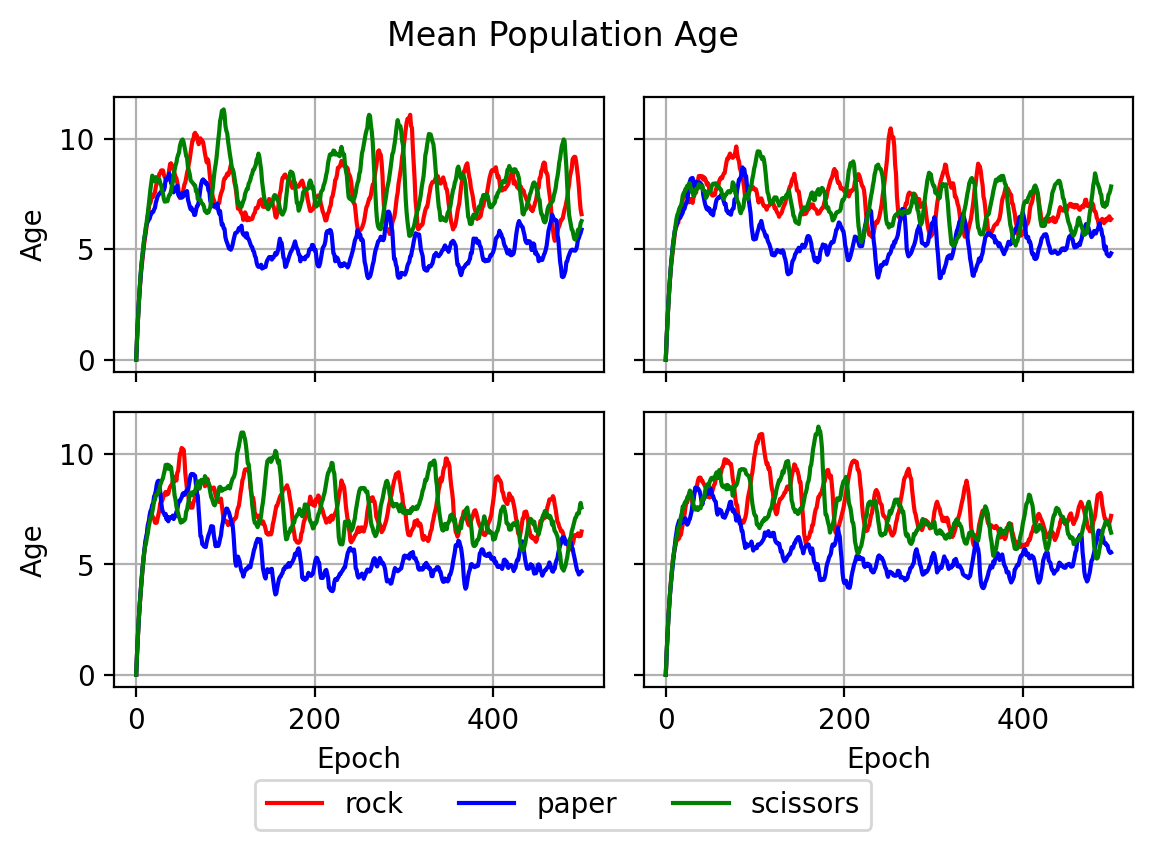

In [ ]:
plot_average_age(g1_2s_df)

### Genetic with Radius 10

For the next experiment all three species are "optimized" with the genetic
evolution strategy, all starting with an initial invasion probability of $0.5$
and a **mating radius** of $10$.

In [43]:
g3_r10_df = pd.read_csv("results/genetic3_r10.csv")
g3_r10_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma,radius
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1,773,869,858,0.499807,0.499916,0.500509,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
2,790,841,869,0.500042,0.499636,0.501086,1.840506,1.869203,1.845800,2,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
3,802,811,887,0.499921,0.499785,0.501310,2.577307,2.646116,2.580609,3,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
4,856,792,852,0.500354,0.499092,0.501880,3.158879,3.347222,3.265258,4,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1033,886,581,0.552364,0.556169,0.545440,9.074540,7.357788,7.641997,495,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1996,986,922,592,0.553613,0.554193,0.543990,9.310345,7.390456,7.508446,496,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1997,958,939,603,0.553878,0.552675,0.544516,9.346555,7.560170,7.412935,497,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1998,919,986,595,0.554948,0.552696,0.544728,9.346028,7.589249,7.205042,498,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10


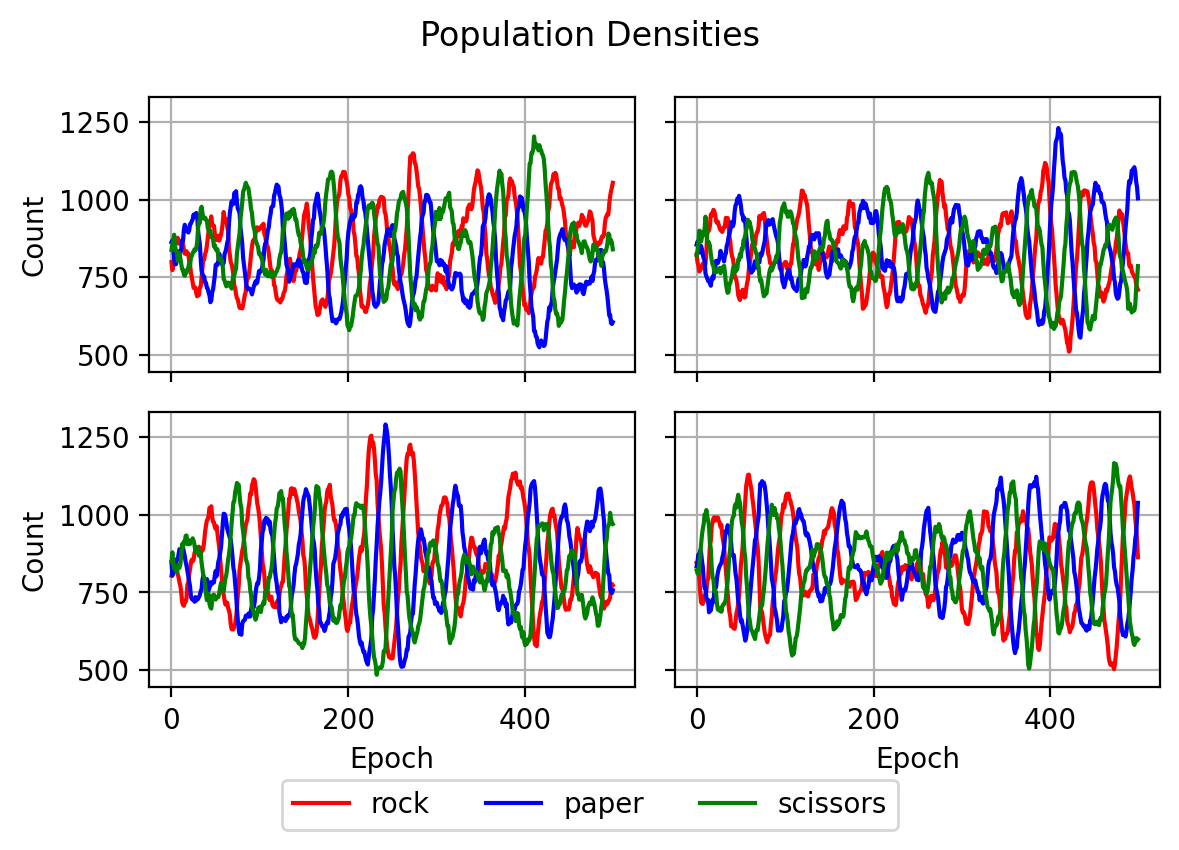

In [44]:
plot_densities(g3_r10_df)

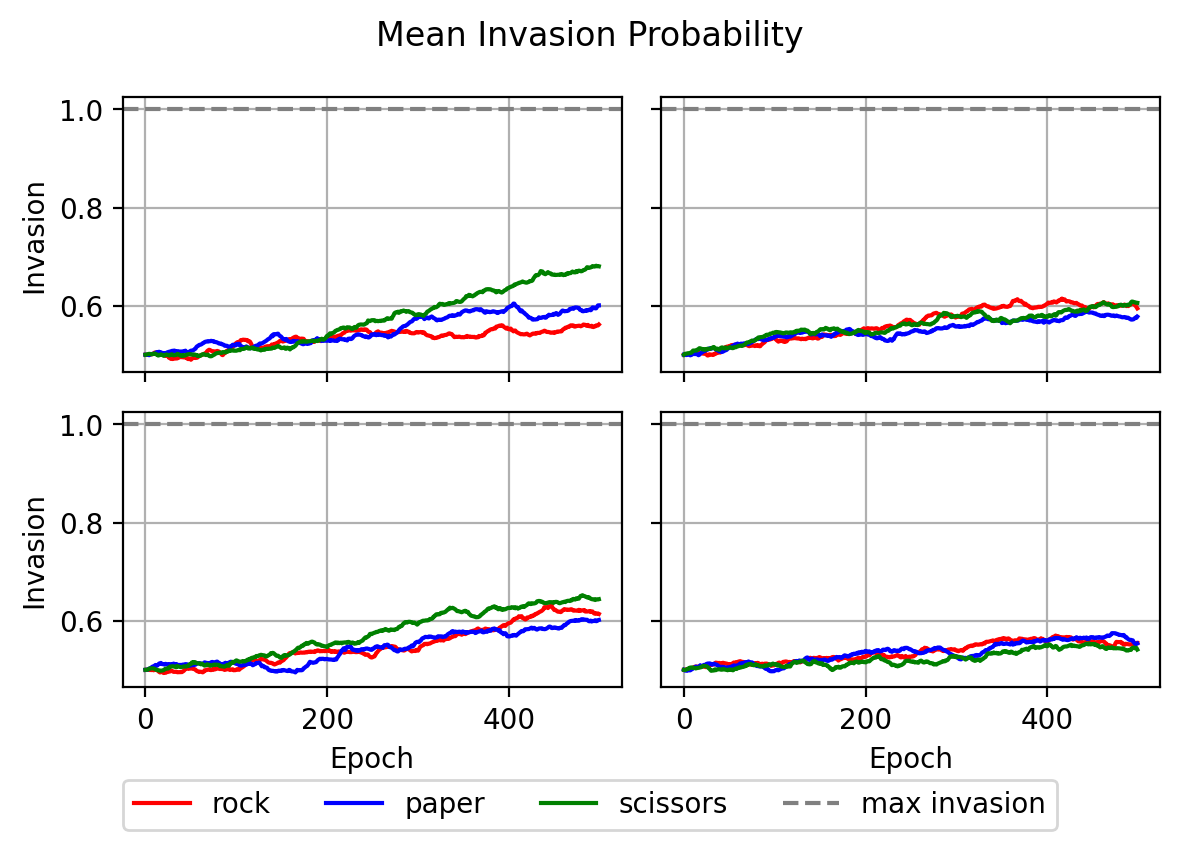

In [45]:
plot_average_invasions(g3_r10_df)

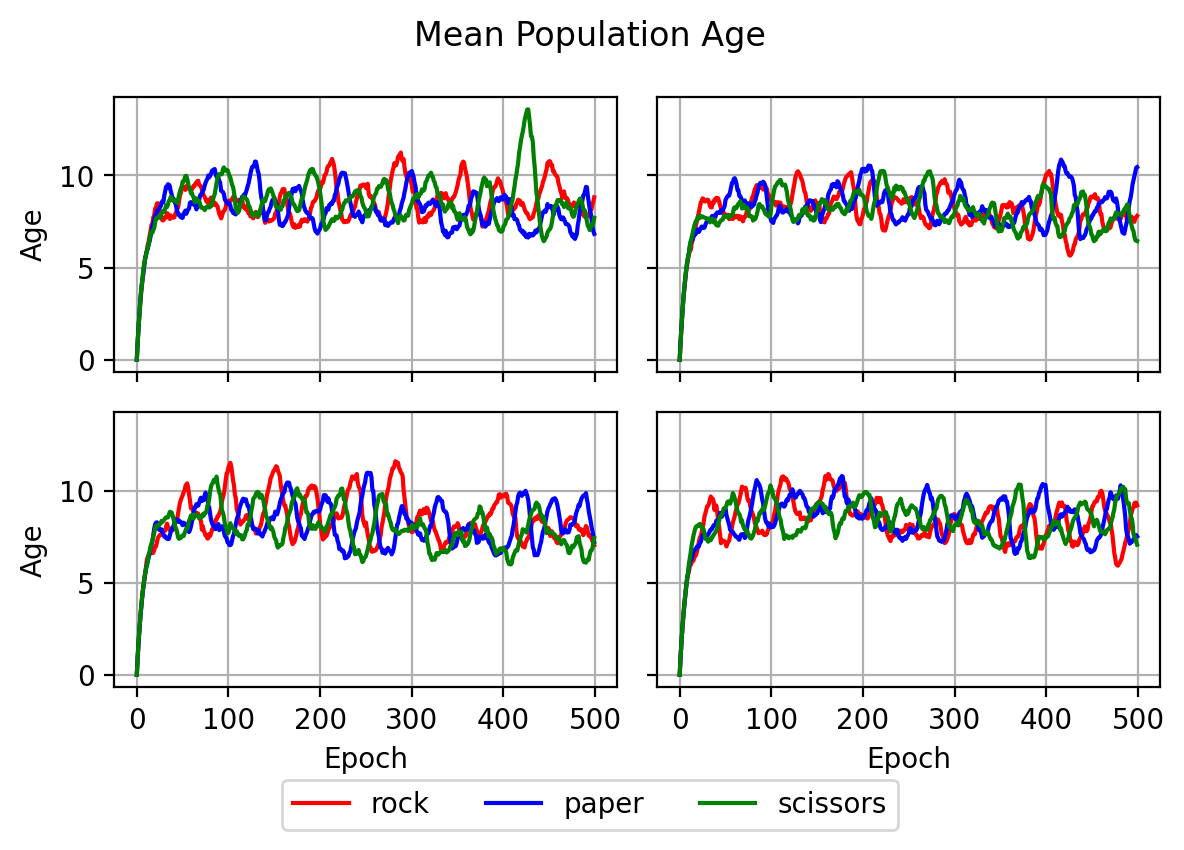

In [46]:
plot_average_age(g3_r10_df)

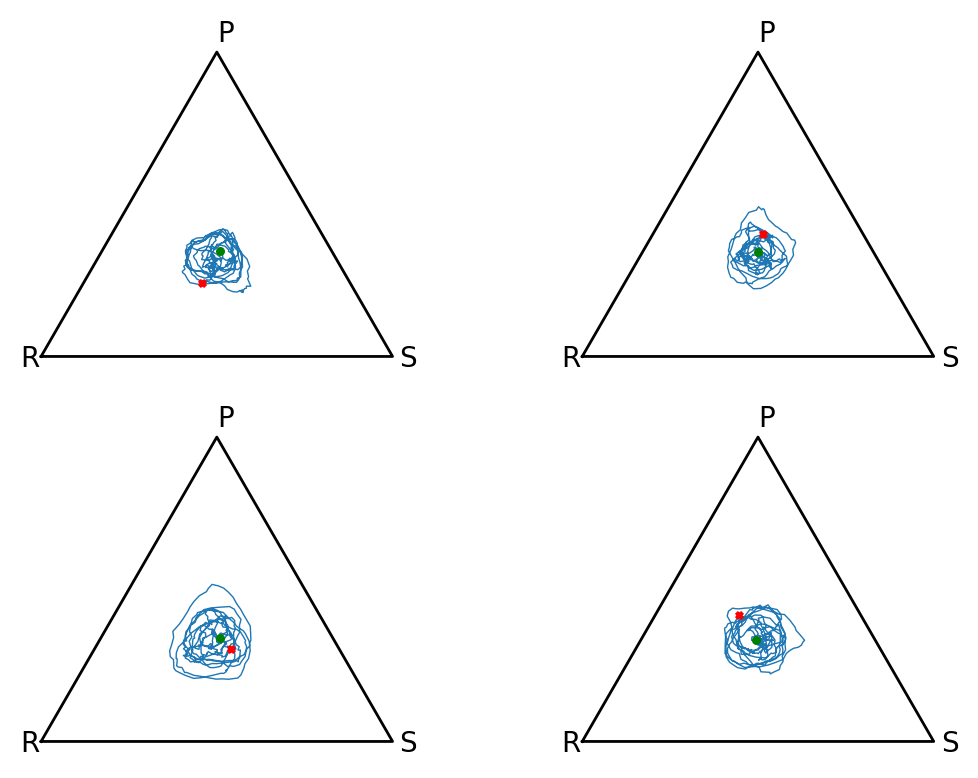

In [47]:
plot_orbits(g3_r10_df)

### Genetic with Radius 20

In [48]:
g3_r20_df = pd.read_csv("results/genetic3_r20.csv")
g3_r20_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma,radius
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1,773,869,858,0.499699,0.499889,0.500596,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
2,785,843,872,0.500873,0.499733,0.501500,1.842038,1.865955,1.845183,2,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
3,784,823,893,0.500800,0.500000,0.501870,2.567602,2.599028,2.569989,3,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
4,826,807,867,0.500645,0.498785,0.502410,3.184019,3.314746,3.256055,4,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,667,741,1092,0.589864,0.623762,0.605007,6.485757,7.630229,7.849817,495,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1996,673,718,1109,0.589775,0.624703,0.606103,6.591382,7.486072,7.885482,496,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1997,703,686,1111,0.589459,0.624847,0.606745,6.510669,7.572886,8.107111,497,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1998,728,669,1103,0.589641,0.627286,0.605730,6.414835,7.476831,8.258386,498,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20


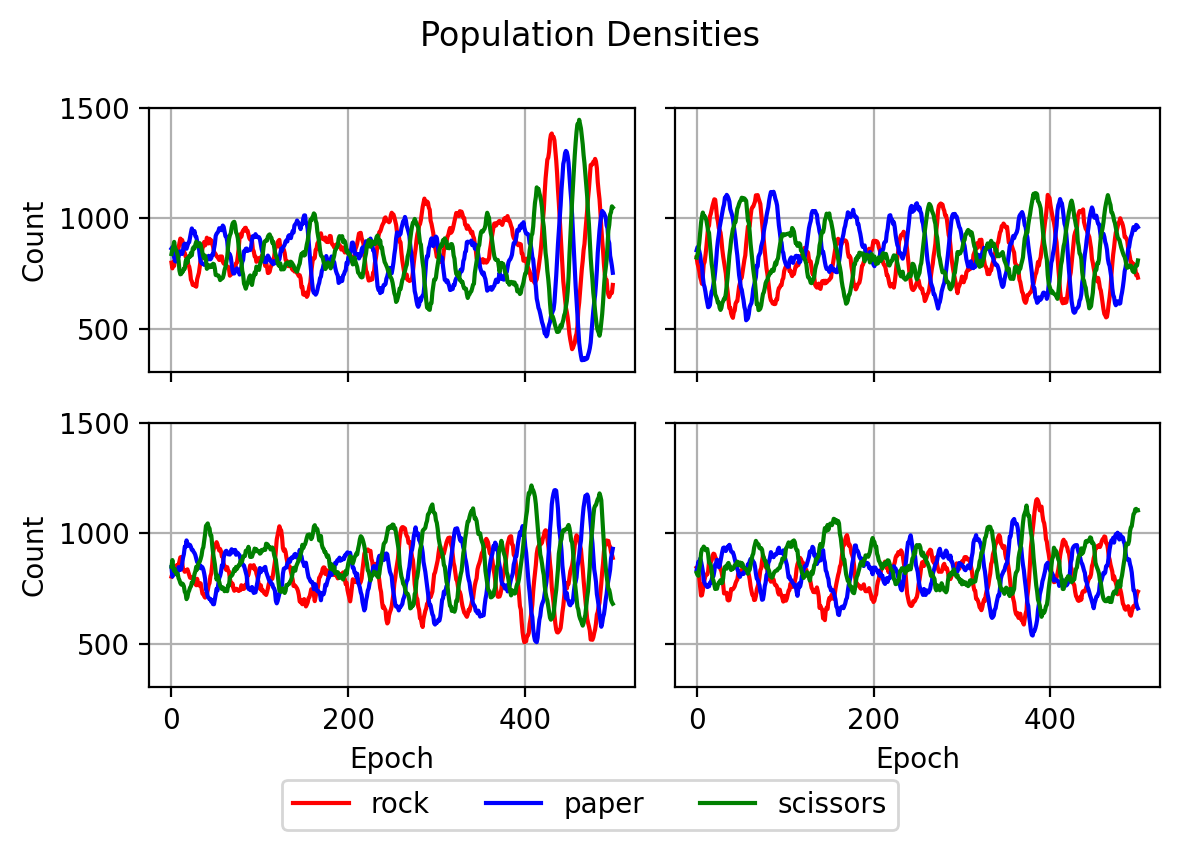

In [49]:
plot_densities(g3_r20_df)

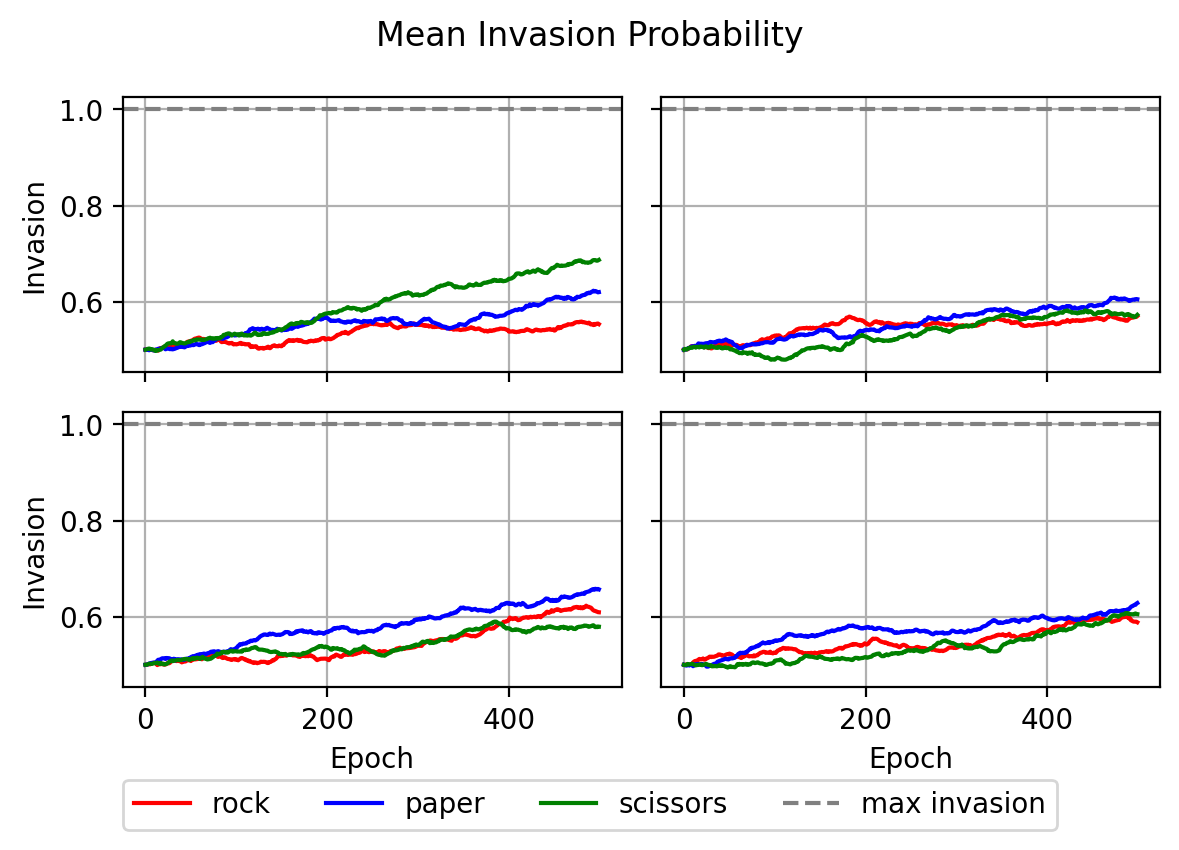

In [50]:
plot_average_invasions(g3_r20_df)

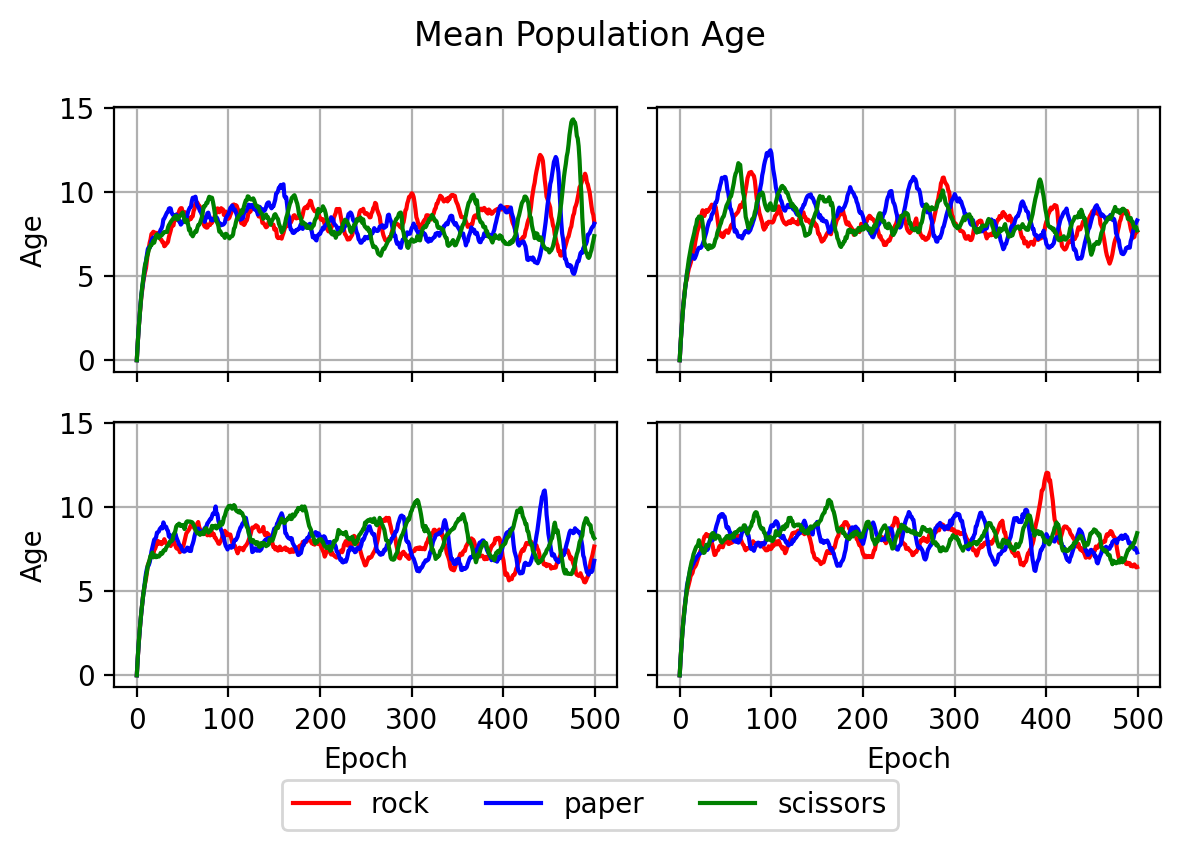

In [51]:
plot_average_age(g3_r20_df)

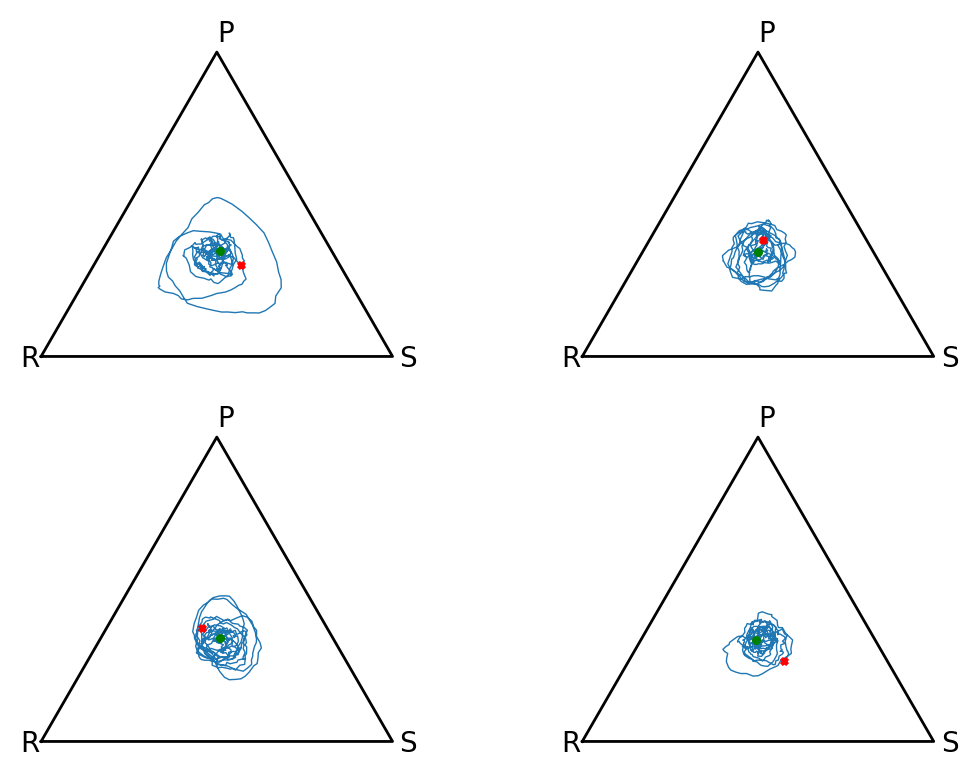

In [52]:
plot_orbits(g3_r20_df)

## Measures

From this work the most interesting things to measure are

- The correlation between age and invasion probability.
- Possible effect of mating radius different sizes.
- Convergence values for age and invasion probability compared to stochastic
  approach.

### Convergence Values of Age and Invasion

For the sake of simplicity the convergence values are just computed as the mean
among same simulations but with different seeds.

In [53]:
fields = [
    "R_density",
    "P_density",
    "S_density",
    "R_invasion",
    "P_invasion",
    "S_invasion",
    "R_age",
    "P_age",
    "S_age",
]

in_df[in_df["epoch"] == 999][fields].mean()

R_density     2153.500000
P_density      934.250000
S_density     2537.250000
R_invasion       0.200000
P_invasion       0.500000
S_invasion       0.500000
R_age           17.889992
P_age            7.614751
S_age           18.456212
dtype: float64

In [54]:
s3_df[s3_df["epoch"] == 999][fields].mean()

R_density     1944.500000
P_density     1845.750000
S_density     1834.750000
R_invasion       0.918130
P_invasion       0.931550
S_invasion       0.935231
R_age            5.276006
P_age            5.178113
S_age            5.194250
dtype: float64

In [ ]:
g3_r10_df[g3_r10_df["epoch"] == 999][fields].mean()

R_density     850.000000
P_density     851.250000
S_density     798.750000
R_invasion      0.581225
P_invasion      0.583454
S_invasion      0.617834
R_age           8.211720
P_age           8.001308
S_age           7.156620
dtype: float64

In [57]:
g3_r20_df[g3_r10_df["epoch"] == 499][fields].mean()

R_density     763.500000
P_density     825.750000
S_density     910.750000
R_invasion      0.580239
P_invasion      0.627568
S_invasion      0.611052
R_age           7.488737
P_age           7.633424
S_age           7.922334
dtype: float64

### Different Radius Effect

The radius length has the effect of amplify the probability of mating with an
high fitness individual.

### Age-Invasion Correlation

There are many, more correct and informative ways to check if there is a
correlation between age and invasion probabilities but for simplicity, we will
consider the mean of the two quantities at each epoch as a set of independent
points.

In [ ]:
print("stochastic invasion-age correlation")
print(f"rock: {s3_df['R_invasion'].corr(s3_df['R_age'])}")
print(f"paper: {s3_df['P_invasion'].corr(s3_df['P_age']):.4f}")
print(f"scissors: {s3_df['S_invasion'].corr(s3_df['S_age']):.4f}")

print()
print("genetic invasion-age correlation")
print(f"rock: {g3_r10_df['R_invasion'].corr(g3_r10_df['R_age']):.4f}")
print(f"paper: {g3_r10_df['P_invasion'].corr(g3_r10_df['P_age']):.4f}")
print(f"scissors: {g3_r10_df['S_invasion'].corr(g3_r10_df['S_age']):.4f}")

stochastic invasion-age correlation
rock: -0.8272541515327378
paper: -0.8256
scissors: -0.8223

genetic invasion-age correlation


NameError: name 'g3_r10_df' is not defined

It seems to be an inverse correlation between the two, the more the invasion
rate grows, the less the individuals live on average.

The genetic policy does not aim for a low invasion probability, it simply
targets older individuals, yet the result is a much slower increase in invasion.

## Conclusions

The most interesting result seems to be the correlation between age and invasion
probabilities but the motivations are not trivial to identify.

It must be pointed out that, even if it seems to be an inverse correlation
betweem the two, species that evolves that way do not seem to ever decrease
their invasion probability on average.

Also, since an individual can't move and the only cause of death is getting
eaten by a predator, the fact that is old almost seems luck. But the fact is
that, as the model is built, two main dynamics seems to be the most probable:

- Short-term longevity gained with high aggression.
- Long-term longevity gained with low aggression.

The first can explain why, also with a genetic policy, the invasion probability
still tends to grow. If an aggressive individual has many nearby preys, it will
hunt and produce many offsprings that still will be influenced to be aggressive,
creating a sort of barrier between their ancestor and other species. This make
the original individual live longer while carrying the genetic trait of being
aggressive.

In the second scenario an individual gets older because is surrounded by other
of its kind or by its preys. In this sense, an individual that does not eat its
preys can live longer by keeping a defence line made of two types of individual,
that in the long run might be a better strategy.